# Uplift Modeling

### Importing Libraries

In [1]:
from __future__ import division
from datetime import datetime, timedelta,date
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import plotly.offline as pyoff
import plotly.graph_objs as go

import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report,confusion_matrix
import sklearn
import xgboost as xgb
from sklearn.model_selection import KFold, cross_val_score, train_test_split

import warnings
warnings.filterwarnings("ignore")

In [2]:
def order_cluster(cluster_field_name, target_field_name,df,ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    df_final = pd.merge(df,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final


In [3]:
df_data = pd.read_csv('../datasets/market_response_model_data.csv')

In [4]:
df_data.head(10)

,recency,history,used_discount,used_bogo,zip_code,is_referral,channel,offer,conversion
0,10,142.44,1,0,Surburban,0,Phone,Buy One Get One,0
1,6,329.08,1,1,Rural,1,Web,No Offer,0
2,7,180.65,0,1,Surburban,1,Web,Buy One Get One,0
3,9,675.83,1,0,Rural,1,Web,Discount,0
4,2,45.34,1,0,Urban,0,Web,Buy One Get One,0
5,6,134.83,0,1,Surburban,0,Phone,Buy One Get One,1
6,9,280.20,1,0,Surburban,1,Phone,Buy One Get One,0
7,9,46.42,0,1,Urban,0,Phone,Buy One Get One,0
8,9,675.07,1,1,Rural,1,Phone,Discount,0
9,10,32.84,0,1,Urban,1,Web,Buy One Get One,0


In [5]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64000 entries, 0 to 63999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   recency        64000 non-null  int64  
 1   history        64000 non-null  float64
 2   used_discount  64000 non-null  int64  
 3   used_bogo      64000 non-null  int64  
 4   zip_code       64000 non-null  object 
 5   is_referral    64000 non-null  int64  
 6   channel        64000 non-null  object 
 7   offer          64000 non-null  object 
 8   conversion     64000 non-null  int64  
dtypes: float64(1), int64(5), object(3)
memory usage: 4.4+ MB


In [6]:
df_data.conversion.mean()

0.14678125

In [7]:
def calc_uplift(df):
    avg_order_value = 25
    
    #calculate conversions for each offer type
    base_conv = df[df.offer == 'No Offer']['conversion'].mean()
    disc_conv = df[df.offer == 'Discount']['conversion'].mean()
    bogo_conv = df[df.offer == 'Buy One Get One']['conversion'].mean()
    
    #calculate conversion uplift for discount and bogo
    disc_conv_uplift = disc_conv - base_conv
    bogo_conv_uplift = bogo_conv - base_conv
    
    #calculate order uplift
    disc_order_uplift = disc_conv_uplift * len(df[df.offer == 'Discount']['conversion'])
    bogo_order_uplift = bogo_conv_uplift * len(df[df.offer == 'Buy One Get One']['conversion'])
    
    #calculate revenue uplift
    disc_rev_uplift = disc_order_uplift * avg_order_value
    bogo_rev_uplift = bogo_order_uplift * avg_order_value
    
    
    print('Discount Conversion Uplift: {0}%'.format(np.round(disc_conv_uplift*100,2)))
    print('Discount Order Uplift: {0}'.format(np.round(disc_order_uplift,2)))
    print('Discount Revenue Uplift: ${0}\n'.format(np.round(disc_rev_uplift,2)))
    
    if len(df[df.offer == 'Buy One Get One']['conversion']) > 0:
          
        print('-------------- \n')
        print('BOGO Conversion Uplift: {0}%'.format(np.round(bogo_conv_uplift*100,2)))
        print('BOGO Order Uplift: {0}'.format(np.round(bogo_order_uplift,2)))
        print('BOGO Revenue Uplift: ${0}'.format(np.round(bogo_rev_uplift,2)))     

In [8]:
calc_uplift(df_data)

Discount Conversion Uplift: 7.66%
Discount Order Uplift: 1631.89
Discount Revenue Uplift: $40797.35

-------------- 

BOGO Conversion Uplift: 4.52%
BOGO Order Uplift: 967.4
BOGO Revenue Uplift: $24185.01


In [9]:
df_data['campaign_group'] = 'treatment'
df_data.loc[df_data.offer == 'No Offer', 'campaign_group'] = 'control'

In [10]:
df_data['target_class'] = 0 #CN
df_data.loc[(df_data.campaign_group == 'control') & (df_data.conversion > 0),'target_class'] = 1 #CR
df_data.loc[(df_data.campaign_group == 'treatment') & (df_data.conversion == 0),'target_class'] = 2 #TN
df_data.loc[(df_data.campaign_group == 'treatment') & (df_data.conversion > 0),'target_class'] = 3 #TR

In [11]:
df_data.target_class.value_counts()

target_class
2    35562
0    19044
3     7132
1     2262
Name: count, dtype: int64

In [12]:
df_data.target_class.value_counts()/len(df_data)

target_class
2    0.555656
0    0.297563
3    0.111437
1    0.035344
Name: count, dtype: float64

In [13]:
kmeans = KMeans(n_clusters=5)
kmeans.fit(df_data[['history']])
df_data['history_cluster'] = kmeans.predict(df_data[['history']])

In [14]:
df_data = order_cluster('history_cluster', 'history',df_data,True)

In [15]:
df_model = df_data.drop(['offer','campaign_group','conversion'],axis=1)
df_model = pd.get_dummies(df_model)

In [16]:
df_model.head()

,recency,history,used_discount,used_bogo,is_referral,target_class,history_cluster,zip_code_Rural,zip_code_Surburban,zip_code_Urban,channel_Multichannel,channel_Phone,channel_Web
0,10,142.44,1,0,0,2,0,False,True,False,False,True,False
1,2,45.34,1,0,0,2,0,False,False,True,False,False,True
2,6,134.83,0,1,0,3,0,False,True,False,False,True,False
3,9,46.42,0,1,0,2,0,False,False,True,False,True,False
4,10,32.84,0,1,1,2,0,False,False,True,False,False,True


In [17]:
#create feature set and labels
X = df_model.drop(['target_class'],axis=1)
y = df_model.target_class

In [18]:
X.columns

Index(['recency', 'history', 'used_discount', 'used_bogo', 'is_referral',
       'history_cluster', 'zip_code_Rural', 'zip_code_Surburban',
       'zip_code_Urban', 'channel_Multichannel', 'channel_Phone',
       'channel_Web'],
      dtype='object')

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=56)

In [20]:
xgb_model = xgb.XGBClassifier().fit(X_train, y_train)

In [21]:
class_probs = xgb_model.predict_proba(X_test)

In [22]:
class_probs[0]

array([0.27202874, 0.01155499, 0.6155185 , 0.10089779], dtype=float32)

In [23]:
X_test['proba_CN'] = class_probs[:,0] 
X_test['proba_CR'] = class_probs[:,1] 
X_test['proba_TN'] = class_probs[:,2] 
X_test['proba_TR'] = class_probs[:,3] 

In [24]:
X_test['uplift_score'] = X_test.eval('proba_CN + proba_TR - proba_TN - proba_CR')

In [25]:
X_test.head()

,recency,history,used_discount,used_bogo,is_referral,history_cluster,zip_code_Rural,zip_code_Surburban,zip_code_Urban,channel_Multichannel,channel_Phone,channel_Web,proba_CN,proba_CR,proba_TN,proba_TR,uplift_score
32277,12,208.97,1,0,0,1,False,False,True,False,True,False,0.272029,0.011555,0.615519,0.100898,-0.254147
12824,6,154.05,1,0,0,0,False,True,False,False,True,False,0.359523,0.044936,0.537441,0.058100,-0.164754
20159,6,73.48,1,0,0,0,False,True,False,False,False,True,0.328418,0.031094,0.556835,0.083654,-0.175857
41575,9,222.28,0,1,1,1,True,False,False,False,True,False,0.313786,0.012444,0.584995,0.088775,-0.194878
10736,10,43.39,1,0,0,0,False,False,True,False,False,True,0.297517,0.017217,0.578001,0.107265,-0.190436


In [26]:
overall_proba = xgb_model.predict_proba(df_model.drop(['target_class'],axis=1))

In [27]:
df_model['proba_CN'] = overall_proba[:,0] 
df_model['proba_CR'] = overall_proba[:,1] 
df_model['proba_TN'] = overall_proba[:,2] 
df_model['proba_TR'] = overall_proba[:,3] 

In [28]:
df_model['uplift_score'] = df_model.eval('proba_CN + proba_TR - proba_TN - proba_CR')

In [29]:
df_data['uplift_score'] = df_model['uplift_score']

In [30]:
df_data.head()

,recency,history,used_discount,used_bogo,zip_code,is_referral,channel,offer,conversion,campaign_group,target_class,history_cluster,uplift_score
0,10,142.44,1,0,Surburban,0,Phone,Buy One Get One,0,treatment,2,0,-0.267349
1,2,45.34,1,0,Urban,0,Web,Buy One Get One,0,treatment,2,0,-0.116338
2,6,134.83,0,1,Surburban,0,Phone,Buy One Get One,1,treatment,3,0,0.042475
3,9,46.42,0,1,Urban,0,Phone,Buy One Get One,0,treatment,2,0,-0.161875
4,10,32.84,0,1,Urban,1,Web,Buy One Get One,0,treatment,2,0,-0.255780


In [31]:
df_data.groupby('offer').uplift_score.mean()

offer
Buy One Get One   -0.204178
Discount          -0.201358
No Offer          -0.138774
Name: uplift_score, dtype: float32

In [32]:
df_data_lift = df_data.copy()
uplift_q_75 = df_data_lift.uplift_score.quantile(0.75)
df_data_lift = df_data_lift[(df_data_lift.offer != 'Buy One Get One') & (df_data_lift.uplift_score > uplift_q_75)].reset_index(drop=True)


In [33]:
len(df_data_lift)

11685

In [34]:
calc_uplift(df_data_lift)

Discount Conversion Uplift: 26.7%
Discount Order Uplift: 1206.61
Discount Revenue Uplift: $30165.29



In [35]:
df_data_lift = df_data.copy()
uplift_q_5 = df_data_lift.uplift_score.quantile(0.5)
df_data_lift = df_data_lift[(df_data_lift.offer != 'Buy One Get One') & (df_data_lift.uplift_score < uplift_q_5)].reset_index(drop=True)


In [36]:
calc_uplift(df_data_lift)

Discount Conversion Uplift: -2.53%
Discount Order Uplift: -296.42
Discount Revenue Uplift: $-7410.54



### Four-Quadrant Uplift Segmentation
Classifying customers into Persuadables, Sure Things, Sleeping Dogs, and Lost Causes

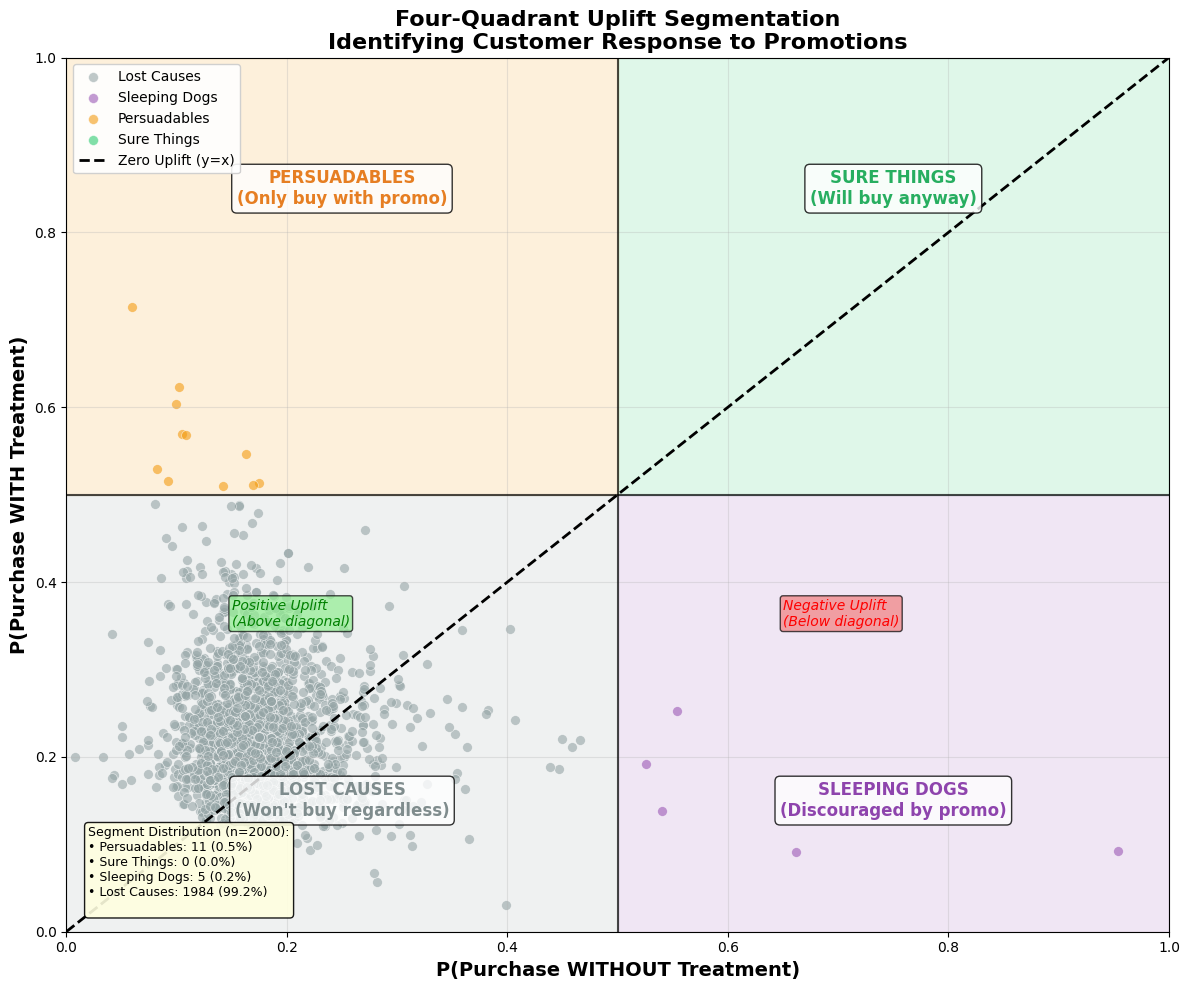


STRATEGIC RECOMMENDATIONS BY SEGMENT

🎯 PERSUADABLES (Target with promotions)
   → High-value targets for marketing campaigns
   → Will convert with the right offer

✅ SURE THINGS (Don't waste promotions)
   → Already likely to purchase
   → Save promotion budget

⚠️  SLEEPING DOGS (Avoid marketing)
   → Promotions may actually decrease conversion
   → Risk of negative ROI

❌ LOST CAUSES (Don't target)
   → Low probability regardless of treatment
   → Focus resources elsewhere


In [37]:
# Four-Quadrant Uplift Segmentation Scatter Plot
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Calculate probabilities for visualization
# P(purchase | no treatment) ~ proba_CN + proba_CR (control outcomes)
# P(purchase | treatment) ~ proba_TN + proba_TR (treatment outcomes)

# For visualization, we'll use the model's class probabilities
# Normalize to create probability-like scores between 0 and 1
df_viz = df_model.copy()

# Create probability scores (scaled for better visualization)
# P(buy without treatment) approximated by CR probability normalized
# P(buy with treatment) approximated by TR probability normalized
df_viz['prob_no_treatment'] = (df_viz['proba_CR'] + df_viz['proba_CN'] * 0.3) 
df_viz['prob_with_treatment'] = (df_viz['proba_TR'] + df_viz['proba_TN'] * 0.15)

# Normalize to 0-1 range
df_viz['prob_no_treatment'] = (df_viz['prob_no_treatment'] - df_viz['prob_no_treatment'].min()) / (df_viz['prob_no_treatment'].max() - df_viz['prob_no_treatment'].min())
df_viz['prob_with_treatment'] = (df_viz['prob_with_treatment'] - df_viz['prob_with_treatment'].min()) / (df_viz['prob_with_treatment'].max() - df_viz['prob_with_treatment'].min())

# Sample for visualization (full dataset would be too dense)
df_sample = df_viz.sample(n=2000, random_state=42)

# Classify into four quadrants
def classify_quadrant(row):
    p_no_treat = row['prob_no_treatment']
    p_with_treat = row['prob_with_treatment']
    
    if p_with_treat > 0.5 and p_no_treat > 0.5:
        return 'Sure Things'  # Will buy anyway
    elif p_with_treat > 0.5 and p_no_treat <= 0.5:
        return 'Persuadables'  # Only buy with promotion
    elif p_with_treat <= 0.5 and p_no_treat > 0.5:
        return 'Sleeping Dogs'  # Discouraged by promo
    else:
        return 'Lost Causes'  # Won't buy regardless

df_sample['segment'] = df_sample.apply(classify_quadrant, axis=1)

# Define colors for each segment
colors = {
    'Sure Things': '#2ecc71',      # Green
    'Persuadables': '#f39c12',     # Orange/Gold
    'Sleeping Dogs': '#9b59b6',    # Purple
    'Lost Causes': '#95a5a6'       # Gray
}

# Create the plot
fig, ax = plt.subplots(figsize=(12, 10))

# Plot background quadrant colors (semi-transparent)
ax.fill_between([0.5, 1], 0.5, 1, color='#2ecc71', alpha=0.15)  # Sure Things
ax.fill_between([0, 0.5], 0.5, 1, color='#f39c12', alpha=0.15)  # Persuadables
ax.fill_between([0.5, 1], 0, 0.5, color='#9b59b6', alpha=0.15)  # Sleeping Dogs
ax.fill_between([0, 0.5], 0, 0.5, color='#95a5a6', alpha=0.15)  # Lost Causes

# Plot scatter points for each segment
for segment in ['Lost Causes', 'Sleeping Dogs', 'Persuadables', 'Sure Things']:
    mask = df_sample['segment'] == segment
    ax.scatter(df_sample.loc[mask, 'prob_no_treatment'], 
               df_sample.loc[mask, 'prob_with_treatment'],
               c=colors[segment], label=segment, alpha=0.6, s=50, edgecolors='white', linewidth=0.5)

# Add diagonal line (y=x) - positive/negative uplift boundary
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Zero Uplift (y=x)')

# Add quadrant dividing lines
ax.axhline(y=0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.7)
ax.axvline(x=0.5, color='black', linestyle='-', linewidth=1.5, alpha=0.7)

# Add quadrant labels
ax.text(0.75, 0.85, 'SURE THINGS\n(Will buy anyway)', fontsize=12, fontweight='bold', 
        ha='center', va='center', color='#27ae60',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.text(0.25, 0.85, 'PERSUADABLES\n(Only buy with promo)', fontsize=12, fontweight='bold',
        ha='center', va='center', color='#e67e22',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.text(0.75, 0.15, 'SLEEPING DOGS\n(Discouraged by promo)', fontsize=12, fontweight='bold',
        ha='center', va='center', color='#8e44ad',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
ax.text(0.25, 0.15, 'LOST CAUSES\n(Won\'t buy regardless)', fontsize=12, fontweight='bold',
        ha='center', va='center', color='#7f8c8d',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Add annotation for positive uplift region
ax.annotate('Positive Uplift\n(Above diagonal)', xy=(0.15, 0.35), fontsize=10, 
            fontstyle='italic', color='green',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightgreen', alpha=0.7))
ax.annotate('Negative Uplift\n(Below diagonal)', xy=(0.65, 0.35), fontsize=10,
            fontstyle='italic', color='red',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='lightcoral', alpha=0.7))

# Formatting
ax.set_xlabel('P(Purchase WITHOUT Treatment)', fontsize=14, fontweight='bold')
ax.set_ylabel('P(Purchase WITH Treatment)', fontsize=14, fontweight='bold')
ax.set_title('Four-Quadrant Uplift Segmentation\nIdentifying Customer Response to Promotions', fontsize=16, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(loc='upper left', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

# Add segment counts
segment_counts = df_sample['segment'].value_counts()
count_text = 'Segment Distribution (n=2000):\n'
for seg in ['Persuadables', 'Sure Things', 'Sleeping Dogs', 'Lost Causes']:
    pct = segment_counts.get(seg, 0) / len(df_sample) * 100
    count_text += f'• {seg}: {segment_counts.get(seg, 0)} ({pct:.1f}%)\n'

ax.text(0.02, 0.02, count_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout()
plt.show()

# Print strategic recommendations
print("\n" + "="*60)
print("STRATEGIC RECOMMENDATIONS BY SEGMENT")
print("="*60)
print("\n🎯 PERSUADABLES (Target with promotions)")
print("   → High-value targets for marketing campaigns")
print("   → Will convert with the right offer")

print("\n✅ SURE THINGS (Don't waste promotions)")  
print("   → Already likely to purchase")
print("   → Save promotion budget")

print("\n⚠️  SLEEPING DOGS (Avoid marketing)")
print("   → Promotions may actually decrease conversion")
print("   → Risk of negative ROI")

print("\n❌ LOST CAUSES (Don't target)")
print("   → Low probability regardless of treatment")
print("   → Focus resources elsewhere")